## Data Loading and Preprocessing

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt


df = pd.read_csv("/content/hmnist_28_28_RGB.csv")
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# reshape + normalization
X = X.reshape(-1, 28, 28, 3).astype('float32') / 255.0


le = LabelEncoder()
y = le.fit_transform(y)
num_classes = len(np.unique(y))


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## CNN Feature Extractor Model

In [ ]:
# CNN + GlobalAveragePooling2D
inputs = Input(shape=(28, 28, 3))

x = Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)
x = Dropout(0.25)(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)
x = Dropout(0.3)(x)

x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)
x = Dropout(0.4)(x)

# GlobalAveragePooling extend of Flatten
x = GlobalAveragePooling2D()(x)
feature_output = Dense(256, activation='relu')(x)
x = Dropout(0.4)(feature_output)

softmax_output = Dense(num_classes, activation='softmax')(x)

temp_model = Model(inputs=inputs, outputs=softmax_output)
temp_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

temp_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,967 (503.78 KB)

 Trainable params: 128,519 (502.03 KB)

 Non-trainable params: 448 (1.75 KB)

## Training the CNN Feature Extractor

In [ ]:
#Training + Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]

history = temp_model.fit(
    X_train, y_train, epochs=100, batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=callbacks
)

Epoch 1/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7978 - loss: 0.5487 - val_accuracy: 0.7673 - val_loss: 0.6353 - learning_rate: 6.2500e-05
Epoch 2/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7977 - loss: 0.5366 - val_accuracy: 0.7838 - val_loss: 0.5857 - learning_rate: 6.2500e-05
Epoch 3/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8027 - loss: 0.5271 - val_accuracy: 0.7853 - val_loss: 0.5876 - learning_rate: 6.2500e-05
Epoch 4/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7948 - loss: 0.5588 - val_accuracy: 0.7853 - val_loss: 0.5835 - learning_rate: 6.2500e-05
Epoch 5/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7878 - loss: 0.5629 - val_accuracy: 0.7728 - val_loss: 0.6184 - learning_rate: 6.2500e-05
Epoch 6/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7892 - loss: 0.5611 - val_accuracy: 0.7843 - val_loss: 0.5946 - learning_rate: 6.2500e-05
Epoch 7/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - acc

## Feature Extraction and Dimensionality Reduction (PCA)

In [ ]:
#Feature Extractor
feature_extractor = Model(inputs=inputs, outputs=feature_output)
X_train_features = feature_extractor.predict(X_train)
X_test_features = feature_extractor.predict(X_test)

print("features:")
print(f"Train features shape: {X_train_features.shape}")
print(f"Test features shape: {X_test_features.shape}")

#PCA
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_features)
X_test_pca = pca.transform(X_test_features)

print(f"🎯 Original features: {X_train_features.shape[1]} → Reduced: {X_train_pca.shape[1]}")

251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
features:
Train features shape: (8012, 256)
Test features shape: (2003, 256)
🎯 Original features: 256 → Reduced: 36


## Training and Evaluating Traditional Models (Random Forest, XGBoost)

In [ ]:
# RandomForest + Hyperparameter Tuning
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}
search_rf = RandomizedSearchCV(rf, param_distributions=param_dist_rf,
                               n_iter=5, scoring='accuracy', cv=3, random_state=42, n_jobs=-1)
search_rf.fit(X_train_pca, y_train)
best_rf = search_rf.best_estimator_

# XGBoost + Hyperparameter Tuning
xgb = XGBClassifier(objective='multi:softmax', num_class=num_classes, eval_metric='mlogloss',
                    use_label_encoder=False, random_state=42)
param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2]
}
search_xgb = RandomizedSearchCV(xgb, param_distributions=param_dist_xgb,
                                n_iter=5, scoring='accuracy', cv=3, random_state=42, n_jobs=-1)
search_xgb.fit(X_train_pca, y_train)
best_xgb = search_xgb.best_estimator_

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [22:11:40] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Model Evaluation and Visualization


🎯 Random Forest Accuracy: 0.7898

📊 Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.54      0.53        65
           1       0.62      0.64      0.63       103
           2       0.56      0.46      0.50       220
           3       0.67      0.17      0.28        23
           4       0.87      0.94      0.90      1341
           5       0.87      0.71      0.78        28
           6       0.58      0.44      0.50       223

    accuracy                           0.79      2003
   macro avg       0.67      0.56      0.59      2003
weighted avg       0.77      0.79      0.78      2003


📌 Random Forest Confusion Matrix:
[[  35    9    9    0    7    0    5]
 [   7   66   12    2   13    0    3]
 [  13   14  101    0   74    0   18]
 [   1    4    4    4    8    1    1]
 [   2    6   28    0 1258    2   45]
 [   0    2    0    0    6   20    0]
 [   8    5   27    0   85    0   98]]

🎯 XGBoost Accuracy: 0.7853

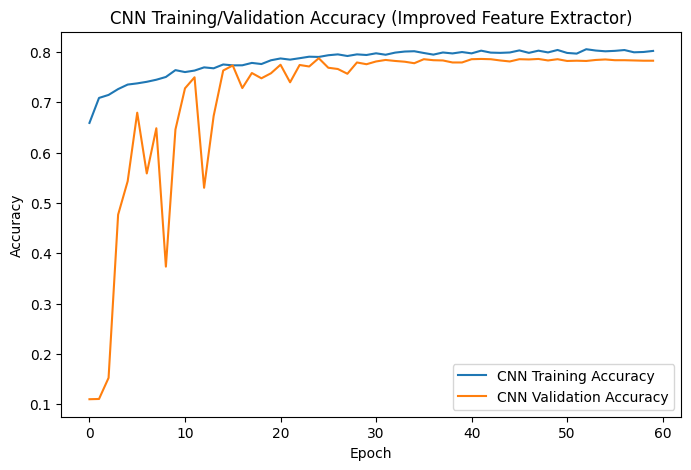

In [ ]:
# 11️⃣ Evaluation
y_pred_rf = best_rf.predict(X_test_pca)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"\n🎯 Random Forest Accuracy: {acc_rf:.4f}")
print("\n📊 Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))
print("\n📌 Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

y_pred_xgb = best_xgb.predict(X_test_pca)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"\n🎯 XGBoost Accuracy: {acc_xgb:.4f}")
print("\n📊 XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))
print("\n📌 XGBoost Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))


plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='CNN Training Accuracy')
plt.plot(history.history['val_accuracy'], label='CNN Validation Accuracy')
plt.title('CNN Training/Validation Accuracy (Improved Feature Extractor)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Model Saving

In [ ]:

temp_model.save("cnn_model.h5")
import joblib
joblib.dump(best_rf, "rf_model.pkl")

joblib.dump(le, "label_encoder.pkl")
joblib.dump(pca, "pca_model.pkl")

['pca_model.pkl']

## Hybrid CNN-Transformer Model

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load CSV and Preprocess

data = pd.read_csv("/content/hmnist_28_28_RGB.csv")
labels = data['label'].values
pixels = data.drop(columns=['label']).values


images = pixels.reshape(-1, 28, 28, 3).astype('float32') / 255.0

# Encode labels
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    images, labels_encoded, test_size=0.2, stratify=labels_encoded, random_state=42
)

# Resize images to make them suitable for CNN/Transformer
X_train = tf.image.resize(X_train, [64, 64])
X_test = tf.image.resize(X_test, [64, 64])

num_classes = len(np.unique(labels_encoded))



# 2. Build Hybrid Model

def create_hybrid_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    # --- CNN Backbone ---
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D(2, 2)(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2, 2)(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.GlobalAveragePooling2D()(x)

    # CNN features → Transformer input
    transformer_input = layers.Reshape((1, x.shape[-1]))(x)

    # --- Simple Transformer Encoder ---
    attn_output = layers.MultiHeadAttention(num_heads=2, key_dim=32)(transformer_input, transformer_input)
    attn_output = layers.LayerNormalization()(attn_output)
    transformer_features = layers.GlobalAveragePooling1D()(attn_output)

    # --- Fusion & Classification ---
    combined = layers.concatenate([x, transformer_features])
    combined = layers.Dense(128, activation='relu')(combined)
    combined = layers.Dropout(0.4)(combined)
    outputs = layers.Dense(num_classes, activation='softmax')(combined)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model

model = create_hybrid_model((64, 64, 3), num_classes)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 16, 16,    │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ conv2d_5[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 128)    │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 128)    │     33,088 │ reshape[0][0],    │
│ (MultiHeadAttentio… │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 1, 128)    │        256 │ multi_head_atten… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     32,896 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 7)         │        903 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 160,391 (626.53 KB)

 Trainable params: 160,391 (626.53 KB)

 Non-trainable params: 0 (0.00 B)

## Training and Evaluating Hybrid Model

Epoch 1/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.6491 - loss: 1.1921 - val_accuracy: 0.6695 - val_loss: 1.0253
Epoch 2/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6718 - loss: 1.0271 - val_accuracy: 0.6695 - val_loss: 0.9967
Epoch 3/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6678 - loss: 1.0085 - val_accuracy: 0.6695 - val_loss: 0.9771
Epoch 4/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6713 - loss: 0.9892 - val_accuracy: 0.6695 - val_loss: 1.0463
Epoch 5/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6777 - loss: 0.9558 - val_accuracy: 0.6695 - val_loss: 0.9429
Epoch 6/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6640 - loss: 0.9467 - val_accuracy: 0.6695 - val_loss: 0.9466
Epoch 7/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6661 - loss: 0.9260 - val_accuracy: 0.6695 - val_loss: 0.9421
Epoch 8/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6692 - loss: 0.9275 - val_a

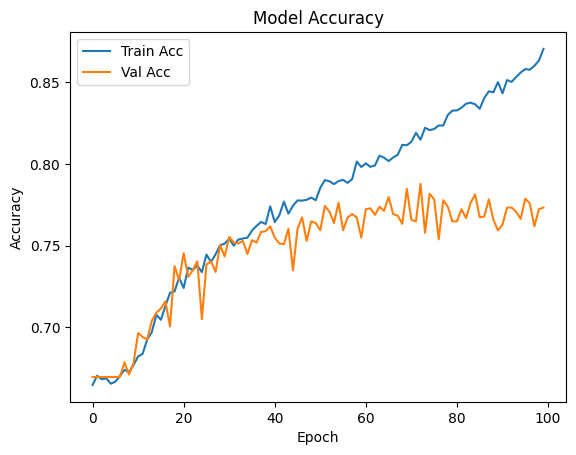

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32
)

test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"✅ Test Accuracy: {test_acc*100:.2f}%")

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()

## Prediction Interface

In [ ]:
import numpy as np
import pandas as pd
from PIL import Image
import io
import ipywidgets as widgets
from IPython.display import display, clear_output
import tensorflow as tf
from tensorflow.keras.models import load_model
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder


try:
    temp_model = load_model("/content/cnn_model.h5")  # CNN model
    best_rf_model = joblib.load("/content/rf_model.pkl")  # RandomForest
    pca_model = joblib.load("/content/pca_model.pkl")  # PCA model
    df_metadata = pd.read_csv("/content/HAM10000_metadata.csv")  # Metadata


    df_hmnist = pd.read_csv("/content/hmnist_28_28_RGB.csv")
    original_labels = df_hmnist['label'].unique()
    label_encoder = LabelEncoder()
    label_encoder.fit(original_labels)


    inputs = temp_model.input
    feature_extractor_output = temp_model.get_layer("dense_3").output
    feature_extractor = tf.keras.Model(inputs=inputs, outputs=feature_extractor_output)

    print("✅ Models, PCA, encoder, and metadata loaded successfully.")

except Exception as e:
    print(f"❌ Error loading model or data: {e}")
    temp_model = None
    best_rf_model = None
    pca_model = None
    label_encoder = None
    df_metadata = None
    feature_extractor = None


label_to_dx = {
    0: "nv",
    1: "mel",
    2: "bkl",
    3: "bcc",
    4: "akiec",
    5: "vasc",
    6: "df"
}


uploader = widgets.FileUpload(
    accept='image/*',
    multiple=False
)
print("Please upload a skin lesion image:")
display(uploader)

def on_upload_change(change):
    if uploader.value and len(uploader.value) > 0:
        try:
            uploaded_file_name = list(uploader.value.keys())[0]
            uploaded_file_info = uploader.value[uploaded_file_name]
            image_bytes = uploaded_file_info['content']
            img = Image.open(io.BytesIO(image_bytes)).convert('RGB')


            clear_output()
            print("Uploaded image:")
            display(img)


            img_resized = img.resize((28,28))
            img_array = np.expand_dims(np.array(img_resized)/255.0, axis=0)


            if feature_extractor:
                img_features = feature_extractor.predict(img_array)


                if pca_model:
                    img_features_pca = pca_model.transform(img_features)
                else:
                    img_features_pca = img_features
                    print("⚠️ PCA model not loaded, using raw features.")


                if best_rf_model and label_encoder:
                    predicted_label_encoded = best_rf_model.predict(img_features_pca)[0]
                    predicted_label_name = label_encoder.inverse_transform([predicted_label_encoded])[0]
                    real_dx_name = label_to_dx.get(predicted_label_encoded, "Unknown")

                    print(f"\n🎯 Predicted Label Number: {predicted_label_encoded}")
                    print(f"🎯 Predicted Label Name: {predicted_label_name}")
                    print(f"🎯 Predicted Cancer Type (dx): {real_dx_name}")


                    if df_metadata is not None:
                        print("\nSome metadata entries for this predicted class:")
                        display(df_metadata[df_metadata['dx'] == real_dx_name].head())


                    fig, ax = plt.subplots(figsize=(3,3))
                    confidence_level = 0.8  # مثال، ممكن تحطي قيمة من RF probabilities
                    ax.pie([confidence_level, 1-confidence_level], colors=["#66bb6a","#eeeeee"], startangle=90)
                    centre_circle = plt.Circle((0,0),0.70,fc='white')
                    fig = plt.gcf()
                    fig.gca().add_artist(centre_circle)
                    ax.axis('equal')
                    plt.title(f"Prediction Confidence ({confidence_level*100:.0f}%) (Dummy)")
                    plt.show()
                else:
                    print("❌ Prediction models or label encoder not loaded.")
            else:
                print("❌ Feature extractor not loaded.")

        except Exception as e:
            print(f"❌ An error occurred during image processing or prediction: {e}")

    else:
        clear_output()
        print("Please upload a skin lesion image:")
        display(uploader)


uploader.observe(on_upload_change, names='value')

❌ Error loading model or data: No such layer: dense_3. Existing layers are: ['input_layer', 'conv2d', 'batch_normalization', 'max_pooling2d', 'dropout', 'conv2d_1', 'batch_normalization_1', 'max_pooling2d_1', 'dropout_1', 'conv2d_2', 'batch_normalization_2', 'max_pooling2d_2', 'dropout_2', 'global_average_pooling2d', 'dense', 'dropout_3', 'dense_1'].
Please upload a skin lesion image:


FileUpload(value={}, accept='image/*', description='Upload')